In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Problem 1

Processing sigma = 0.71
Processing sigma = 1.41
Processing sigma = 2.12
Processing sigma = 2.83
Processing sigma = 3.54
Processing sigma = 4.24
Processing sigma = 4.95
Processing sigma = 5.66
Processing sigma = 6.36
Processing sigma = 7.07


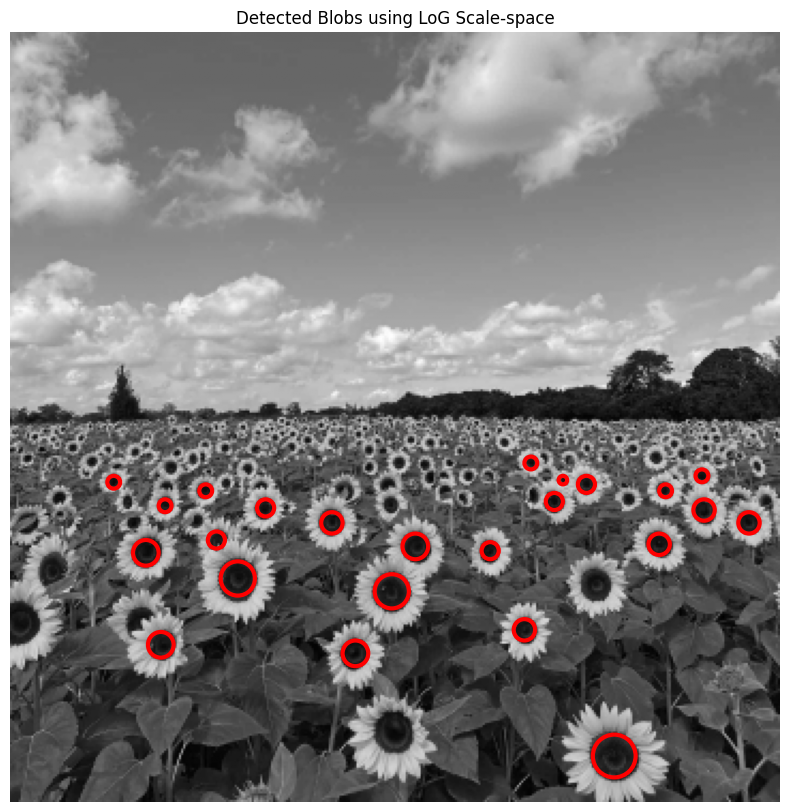

Largest blob at (282, 338), radius = 10.0px, sigma = 7.07


In [90]:
# Load and normalize grayscale image
img = cv.imread('src/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
assert img is not None, "Image not found. Check path."
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY).astype(np.float32) / 255.0

# Display image setup
plt.figure(figsize=(10, 10))
plt.imshow(gray, cmap='gray')
plt.axis('off')
ax = plt.gca()

sigma_range = range(1, 11)      # Loop from sigma=1 to 10/√2
threshold = 0.12                # Detection threshold
neighborhood = 3                # Neighborhood window size for maxima detection
detections = []                 # Store detected blobs

# Iterate over scales (σ)
for r in sigma_range:
    sigma = r / np.sqrt(2)
    print(f"Processing sigma = {sigma:.2f}")

    # Define kernel half-width (3σ rule)
    hw = int(round(3 * sigma))
    X, Y = np.meshgrid(np.arange(-hw, hw + 1), np.arange(-hw, hw + 1))

    # Compute normalized Laplacian of Gaussian (LoG) kernel
    blur = cv.GaussianBlur(gray, (0, 0), sigma)
    lap = cv.Laplacian(blur, cv.CV_32F)
    response = sigma**2 * np.abs(lap)
    response_sq = np.square(response)  # make all responses positive

    # Local maxima detection (simple 2D neighborhood)
    H, W = response_sq.shape
    for i in range(neighborhood, H - neighborhood):
        for j in range(neighborhood, W - neighborhood):
            patch = response_sq[i - neighborhood:i + neighborhood + 1, j - neighborhood:j + neighborhood + 1]
            if response_sq[i, j] == np.max(patch) and response_sq[i, j] >= threshold:
                detections.append((j, i, sigma))  # store (x, y, sigma)

filtered_detections = []
min_dist = 4  # minimum distance between blob centers

for x, y, sigma in detections:
    if all(np.hypot(x - fx, y - fy) > min_dist for fx, fy, _ in filtered_detections):
        filtered_detections.append((x, y, sigma))

# Draw detected circles
for x, y, sigma in filtered_detections:
    radius = np.sqrt(2) * sigma
    circ = plt.Circle((x, y), radius, color='r', linewidth=3, fill=False)
    ax.add_patch(circ)

plt.title('Detected Blobs using LoG Scale-space')
plt.show()

# Report largest blob
if filtered_detections:
    largest_blob = max(filtered_detections, key=lambda b: np.sqrt(2) * b[2])
    x, y, sigma = largest_blob
    radius = np.sqrt(2) * sigma
    print(f"Largest blob at ({int(x)}, {int(y)}), radius = {radius:.1f}px, sigma = {sigma:.2f}")
else:
    print("No blobs detected above threshold.")


### Problem 2 - Line & Circle Estimation Using RANSAC

LINE ESTIMATION USING RANSAC

Best Line Parameters [a, b, d]: [-0.70250177 -0.711682   -1.38849715]
Number of Inliers: 40

CIRCLE ESTIMATION USING RANSAC

Best Circle Parameters [x0, y0, r]: [2.15715872 3.13790081 9.98955283]
Number of Circle Inliers: 36


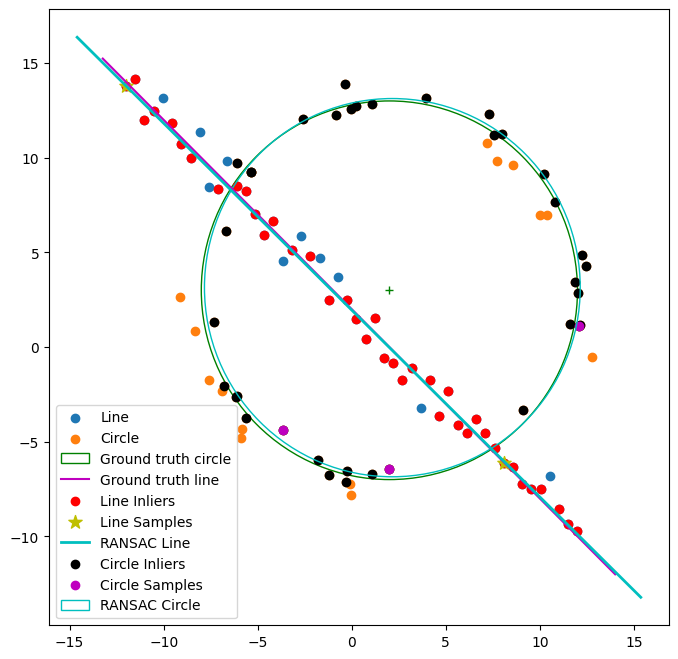

In [ ]:
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
#import tikzplotlib

# np.random.seed(0)
N= 100
half_n =N//2
r = 10
x0_gt , y0_gt = 2, 3 # Center
s = r/16

t = np.random.uniform(0, 2*np.pi , half_n)
n = s*np.random.randn(half_n)
x, y = x0_gt + (r + n)*np.cos(t), y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n ,1) , y.reshape(half_n ,1)))
s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n ,1) , y.reshape(half_n ,1)))
X = np.vstack((X_circ , X_line )) # All points

fig , ax = plt.subplots(1,1, figsize =(8 ,8))
ax.scatter (X_line [: ,0] , X_line [: ,1] , label= 'Line' )
ax.scatter ( X_circ [: ,0] , X_circ [: ,1] , label= 'Circle' )
circle_gt = plt.Circle ((x0_gt ,y0_gt) , r , color= 'g' , fill=False , label= 'Ground truth circle' )
ax.add_patch(circle_gt)
ax.plot((x0_gt), (y0_gt), '+', color='g')

x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt.plot(x_, y_, color='m', label='Ground truth line')
plt.legend()

# ---------------------------------------------------
# 3. RANSAC for Line Estimation
# ---------------------------------------------------
print('LINE ESTIMATION USING RANSAC')

def unit_norm_constraint(params):
    a, b = params[0], params[1]
    return a**2 + b**2 - 1

constraint = {'type': 'eq', 'fun': unit_norm_constraint}

def line_total_least_squares(params, indices):
    a, b, d = params
    error = (a * X[indices, 0] + b * X[indices, 1] - d)**2
    return np.sum(error)

def line_consensus_set(X, params, threshold):
    """Find inliers based on perpendicular distance to line."""
    a, b, d = params
    distances = np.abs(a * X[:, 0] + b * X[:, 1] - d)
    return distances < threshold

# --- RANSAC parameters ---
max_iterations = 500  # Increased
line_inlier_ratio = 0.4
min_inliers_required = int(line_inlier_ratio * N)
distance_threshold = 0.7  # Reduced

best_line_error = np.inf
best_line_params = None
best_line_inliers = None
best_line_samples = None

for iteration in range(max_iterations):
    # Randomly select minimal sample set
    sample_indices = np.random.choice(N, 2, replace=False)
    
    # Better initial guess from sample points
    p1, p2 = X[sample_indices[0]], X[sample_indices[1]]
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    norm = np.sqrt(dx**2 + dy**2)
    if norm < 1e-6:  # Skip if points are too close
        continue
    a_init, b_init = -dy/norm, dx/norm
    d_init = a_init * p1[0] + b_init * p1[1]
    initial_guess = np.array([a_init, b_init, d_init])
    
    res = minimize(line_total_least_squares, x0=initial_guess, 
                   args=(sample_indices,), constraints=constraint, tol=1e-6)
    
    inliers = line_consensus_set(X, res.x, distance_threshold)
    
    if np.sum(inliers) >= min_inliers_required:
        # Refit using all inliers
        inlier_indices = np.where(inliers)[0]
        refined = minimize(line_total_least_squares, x0=res.x, 
                          args=(inlier_indices,), constraints=constraint, tol=1e-6)
        
        if refined.fun < best_line_error:
            best_line_error = refined.fun
            best_line_params = refined.x
            best_line_inliers = inliers
            best_line_samples = sample_indices

print("\nBest Line Parameters [a, b, d]:", best_line_params)
print("Number of Inliers:", np.sum(best_line_inliers))

# Line plotting
a, b, d = best_line_params
x_vals = np.array(ax.get_xlim())
y_vals = (d - a*x_vals) / b  # CORRECTED FORMULA

ax.scatter(X[best_line_inliers, 0], X[best_line_inliers, 1], c='r', label='Line Inliers')
ax.scatter(X[best_line_samples, 0], X[best_line_samples, 1], c='y', s=100, marker='*', label='Line Samples')
ax.plot(x_vals, y_vals, 'c', linewidth=2, label='RANSAC Line')

# ---------------------------------------------------
# 4. RANSAC for Circle Estimation
# ---------------------------------------------------
print('\nCIRCLE ESTIMATION USING RANSAC')

# Use only points not belonging to the line
circle_points = X[~best_line_inliers]

def circle_total_least_squares(params, indices):
    x0, y0, r = params
    xi, yi = circle_points[indices].T
    error = (np.sqrt((xi - x0)**2 + (yi - y0)**2) - r)**2
    return np.sum(error)

def circle_consensus_set(points, params, threshold):
    """Find circle inliers based on radial distance."""
    x0, y0, r = params
    distances = np.abs(np.linalg.norm(points - [x0, y0], axis=1) - r)
    return distances < threshold

# --- RANSAC parameters ---
circle_threshold = 1.0
circle_min_inliers = 35
max_iterations = 100
best_circle_error = np.inf
best_circle_params = None
best_circle_inliers = None
best_circle_samples = None

for iteration in range(max_iterations):
    # Randomly select 3 points
    sample_indices = np.random.randint(0, len(circle_points), 3)
    initial_guess = np.array([0, 0, 5])

    res = minimize(circle_total_least_squares, x0=initial_guess,
                   args=(sample_indices,), tol=1e-6)
    inliers = circle_consensus_set(circle_points, res.x, circle_threshold)

    if np.sum(inliers) > circle_min_inliers:
        inlier_indices = np.where(inliers)[0]
        refined = minimize(circle_total_least_squares, x0=res.x, 
                   args=(inlier_indices,), tol=1e-6)
        if refined.fun < best_circle_error:
            best_circle_error = refined.fun
            best_circle_params = refined.x
            best_circle_inliers = inliers
            best_circle_samples = sample_indices

print("\nBest Circle Parameters [x0, y0, r]:", best_circle_params)
print("Number of Circle Inliers:", np.sum(best_circle_inliers))

# Circle plotting
ax.scatter(circle_points[best_circle_inliers, 0], circle_points[best_circle_inliers, 1], c='k', label='Circle Inliers')
ax.scatter(circle_points[best_circle_samples, 0], circle_points[best_circle_samples, 1], c='m', label='Circle Samples')
fitted_circle = plt.Circle(best_circle_params[:2], best_circle_params[2], color='c', fill=False, label='RANSAC Circle')
ax.add_patch(fitted_circle)
ax.legend()
plt.show()

#### (d) What happens if we fit the circle first?
Fitting the circle first mixes the (roughly) collinear points with true circle points. Because a circle model has 3 DoF, many random 3‑point samples that include 1–2 line points plus 1–2 circle points can still produce a spurious circle of large radius or shifted center that (with a loose threshold) absorbs a portion of the line as “inliers.” This reduces the purity of the remaining set and degrades the subsequent line fit (fewer clean inliers, higher variance, possibly biased normal). The line, however, is easier to separate first because: (1) its inlier set is compact in the normal‑distance metric; (2) the circle outliers are well distributed and unlikely to form a dominant accidental line; and (3) removing the line leaves a nearly pure circular arc—making radius/center estimation far more stable. In short: line‑first yields clean segmentation; circle‑first risks contaminating both models and poorer parameter estimates.

### Problem 3 - Image Superimposing

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def superimpose_image_with_homography(base_path, overlay_path, window_title="Base Image", output_title="Result"):
    clicked_points = []

    # Load images
    base_img_bgr = cv.imread(base_path)
    overlay_bgr = cv.imread(overlay_path)

    if base_img_bgr is None or overlay_bgr is None:
        raise FileNotFoundError(f"Check file paths:\n{base_path}\n{overlay_path}")

    base_img = base_img_bgr.astype(np.float32) / 255.0
    overlay = overlay_bgr.astype(np.float32) / 255.0
    display_img = base_img.copy()

    # Mouse callback to collect 4 points
    def point_selection(action, x, y, flags, param):
        nonlocal clicked_points, display_img
        if action == cv.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
            clicked_points.append((x, y))
            cv.circle(display_img, (x, y), 4, (0, 0, 1), -1)
            cv.imshow(window_title, display_img)

    cv.imshow(window_title, display_img)
    cv.setMouseCallback(window_title, point_selection)

    print("Click four corner points on the target surface in order (clockwise or counterclockwise).")
    while len(clicked_points) < 4:
        if cv.waitKey(20) & 0xFF == 27:
            break
    cv.destroyAllWindows()

    if len(clicked_points) < 4:
        raise RuntimeError("Four destination points were not selected.")

    destination_points = np.array(clicked_points, dtype=np.float32)

    #  Define source points from overlay image 
    h2, w2 = overlay.shape[:2]
    source_points = np.float32([
        [0, 0],
        [w2 - 1, 0],
        [w2 - 1, h2 - 1],
        [0, h2 - 1],
    ])

    # Compute Homography
    H = cv.getPerspectiveTransform(source_points, destination_points)

    # Warp overlay
    warped_overlay = cv.warpPerspective(overlay, H, (base_img.shape[1], base_img.shape[0]))

    # Create mask and blend
    mask = cv.warpPerspective(np.ones((h2, w2), dtype=np.float32), H, (base_img.shape[1], base_img.shape[0]))
    mask = np.clip(mask, 0.0, 1.0)[:, :, None]
    blended = base_img * (1.0 - mask) + warped_overlay * mask

    # Display result
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv.cvtColor(base_img, cv.COLOR_BGR2RGB))
    plt.title('Base Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv.cvtColor(overlay_bgr.astype(np.float32)/255.0, cv.COLOR_BGR2RGB))
    plt.title('Overlay Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv.cvtColor(blended, cv.COLOR_BGR2RGB))
    plt.title(output_title)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("Image shape:", base_img.shape)
    print("Overlay shape:", overlay.shape)
    print("Selected Points:", clicked_points)
    print("Homography Matrix:\n", H)

    return blended, H, clicked_points


Click four corner points on the target surface in order (clockwise or counterclockwise).


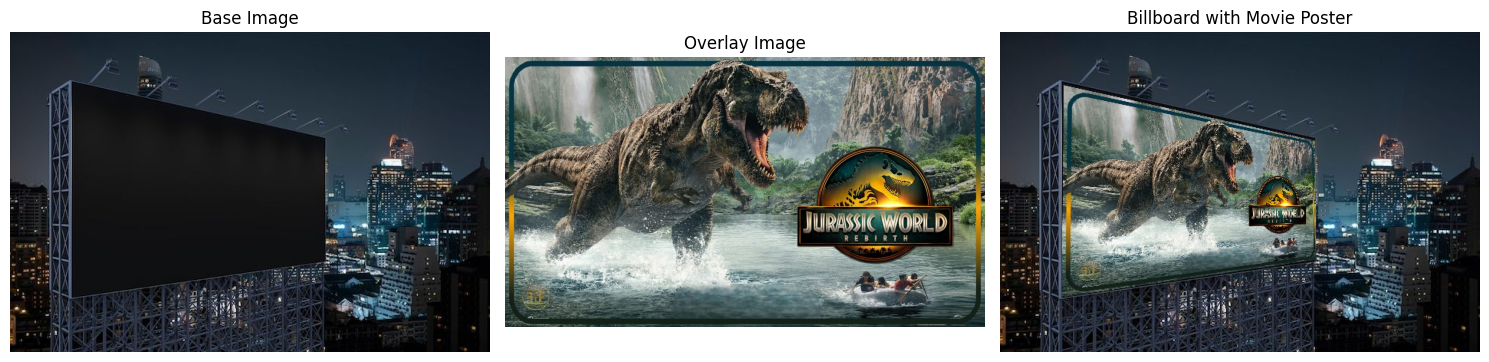

Image shape: (417, 626, 3)
Overlay shape: (720, 1280, 3)
Selected Points: [(83, 69), (410, 141), (412, 296), (80, 345)]
Homography Matrix:
 [[ 5.03915446e-01 -6.36721645e-03  8.30000000e+01]
 [ 1.41666713e-01  3.74401602e-01  6.90000000e+01]
 [ 6.05480378e-04 -2.74344337e-05  1.00000000e+00]]


In [11]:
blended, H, points = superimpose_image_with_homography(
    base_path="src/blank_billboard.jpeg",
    overlay_path="src/movie_poster.jpg",
    output_title='Billboard with Movie Poster'
)


Click four corner points on the target surface in order (clockwise or counterclockwise).


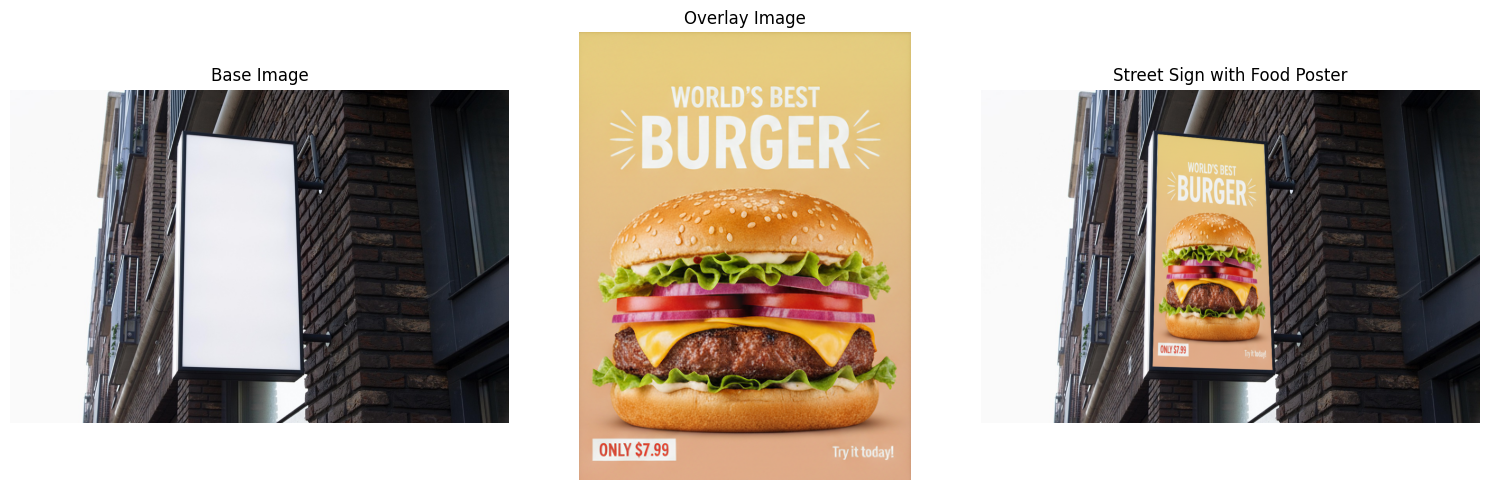

Image shape: (854, 1280, 3)
Overlay shape: (497, 368, 3)
Selected Points: [(454, 113), (725, 139), (747, 717), (440, 708)]
Homography Matrix:
 [[ 8.00197851e-01 -1.34238195e-01  4.54000000e+02]
 [ 8.26890650e-02  1.02901320e+00  1.13000000e+02]
 [ 8.52113549e-05 -2.40937247e-04  1.00000000e+00]]


In [13]:
blended, H, points = superimpose_image_with_homography(
    base_path="src/street_sign.jpg",
    overlay_path="src/food_poster.png",
    output_title='Street Sign with Food Poster'
)

### Problem 4 - Image Stiching

Image 1: 2674 keypoints
Image 5: 3923 keypoints
Raw matches (pairs): 2674
Good matches after ratio test: 87


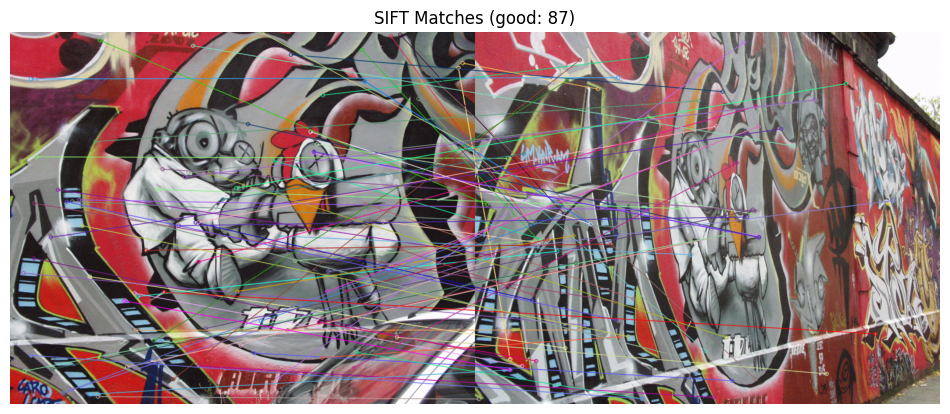

In [2]:
# Load images
img1 = cv.imread("src/graf/img1.ppm")
img5 = cv.imread("src/graf/img5.ppm")
if img1 is None or img5 is None:
    raise FileNotFoundError(f"File could not load")

# Convert to grayscale and RGB
img1_gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
img5_gray = cv.cvtColor(img5, cv.COLOR_BGR2GRAY)
img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img5_rgb = cv.cvtColor(img5, cv.COLOR_BGR2RGB)

# Create SIFT detector
sift = cv.SIFT_create()

# Detect keypoints and descriptors
keypoints1, descriptors1 = sift.detectAndCompute(img1_gray, None)
keypoints5, descriptors5 = sift.detectAndCompute(img5_gray, None)

print(f"Image 1: {len(keypoints1)} keypoints")
print(f"Image 5: {len(keypoints5)} keypoints")

# Brute-Force matcher with default L2 (SIFT uses float descriptors)
bf = cv.BFMatcher(cv.NORM_L2, crossCheck=False)

# KNN match (k=2) for Lowe's ratio test
raw_matches = bf.knnMatch(descriptors1, descriptors5, k=2)

# Apply Lowe ratio test
ratio_thresh = 0.75
good_matches = []
for m, n in raw_matches:
    if m.distance < ratio_thresh * n.distance:
        good_matches.append(m)

print(f"Raw matches (pairs): {len(raw_matches)}")
print(f"Good matches after ratio test: {len(good_matches)}")

# sort matches by distance
good_matches = sorted(good_matches, key=lambda m: m.distance)

# Draw matches
matched_img = cv.drawMatches(
    img1_rgb, keypoints1,
    img5_rgb, keypoints5,
    good_matches, None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(12, 6))
plt.imshow(matched_img)
plt.title(f'SIFT Matches (good: {len(good_matches)})')
plt.axis('off')
plt.show()

# Prepare point arrays for homography
if len(good_matches) >= 4:
    # img1 -> img5
    pts1 = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
    pts5 = np.float32([keypoints5[m.trainIdx].pt for m in good_matches])
else:
    pts1, pts5 = None, None
    raise RuntimeError("Not enough matches for homography (need at least 4).")

C:\Users\Naveen\AppData\Local\Temp\ipykernel_27592\2856551622.py:4: RuntimeWarning: divide by zero encountered in divide
  proj /= proj[:, 2:3]                                     # normalize
C:\Users\Naveen\AppData\Local\Temp\ipykernel_27592\2856551622.py:4: RuntimeWarning: invalid value encountered in divide
  proj /= proj[:, 2:3]                                     # normalize


[[ 6.97308808e-01  1.01446191e-01  2.10521402e+02]
 [ 2.75663814e-01  1.32170517e+00 -7.34385177e+01]
 [ 6.08087298e-04  4.75209933e-05  1.00000000e+00]]


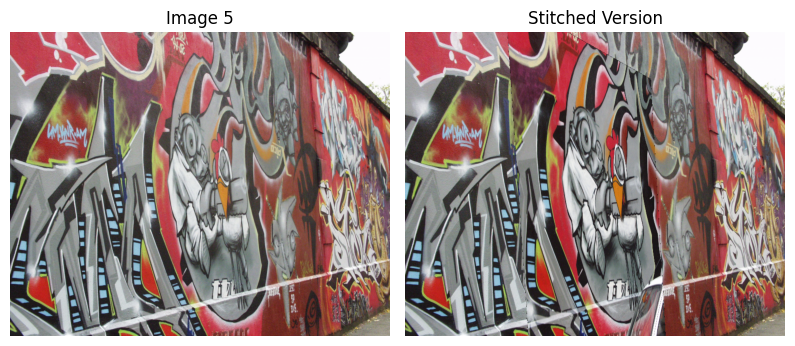

In [14]:
def reprojection_errors(src_pts, dst_pts, H):
    src_h = np.hstack([src_pts, np.ones((len(src_pts), 1))])  # [N,3]
    proj = (H @ src_h.T).T                                   # [N,3]
    proj /= proj[:, 2:3]                                     # normalize
    return np.linalg.norm(proj[:, :2] - dst_pts, axis=1)     # [N]

def RANSAC(point_1, point_2, threshold=40, iterations=1000, min_inlier_count=10):
    num_inliers = 0
    best_homography = None

    points = np.hstack((point_1, point_2))  # shape (N,4)

    for _ in range(iterations):
        np.random.shuffle(points)
        p1 = points[:4, :2].astype(np.float32)
        p2 = points[:4, 2:].astype(np.float32)
        p1_rem = points[4:, :2]
        p2_rem = points[4:, 2:]

        H = cv.findHomography(p1, p2, 0)[0]
        if H is None:
            continue

        errors = reprojection_errors(p1_rem, p2_rem, H)
        inlier_mask = errors < threshold
        inliers = np.hstack([p1_rem[inlier_mask], p2_rem[inlier_mask]])

        if len(inliers) > num_inliers and len(inliers) >= min_inlier_count:
            num_inliers = len(inliers)
            best_homography = H

    return best_homography

# SIFT feature extraction
sift = cv.SIFT_create(nOctaveLayers=3, contrastThreshold=0.08, edgeThreshold=12, sigma=0.9)

keypoints1, descriptors1 = sift.detectAndCompute(img1, None)  # img1 = source
keypoints5, descriptors5 = sift.detectAndCompute(img5, None)  # img5 = destination

bf_matcher = cv.BFMatcher()
matches = bf_matcher.knnMatch(descriptors5, descriptors1, k=2)

good_matches = []
keypoints5_matched = []
keypoints1_matched = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
        keypoints5_matched.append(keypoints5[m.queryIdx].pt)  # img5
        keypoints1_matched.append(keypoints1[m.trainIdx].pt)  # img1

keypoints1_matched = np.array(keypoints1_matched)
keypoints5_matched = np.array(keypoints5_matched)

H = RANSAC(keypoints1_matched, keypoints5_matched)  # img1 -> img5
print(H)

# Warp source (img1) into destination frame (img5)
img_warped = cv.warpPerspective(img1, H, (img5.shape[1], img5.shape[0]))

# Create mask
warp_gray = cv.cvtColor(img_warped, cv.COLOR_BGR2GRAY)
_, mask_inv = cv.threshold(warp_gray, 0, 1, cv.THRESH_BINARY_INV)
mask_inv = mask_inv[..., None]  # shape (H,W,1)
img5_background = img5 * mask_inv
img_blended = cv.addWeighted(img5_background, 1.0, img_warped, 1.0, 0.0)

plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(cv.cvtColor(img5, cv.COLOR_BGR2RGB))
plt.title("Image 5")  # (label kept as you had)
plt.axis("off")

plt.subplot(132)
plt.imshow(cv.cvtColor(img_blended, cv.COLOR_BGR2RGB))
plt.title("Stitched Version")
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
import os
import numpy as np

# --- Load ground truth homography (img1 -> img5) ---
H_gt = None
gt_path = None

# Try both with and without .txt extension
if os.path.exists("src/graf/H1to5p"):
    gt_path = "src/graf/H1to5p"
elif os.path.exists("src/graf/H1to5p.txt"):
    gt_path = "src/graf/H1to5p.txt"

if gt_path is None:
    raise FileNotFoundError("Ground truth homography file (H1to5p) not found.")
else:
    H_gt = np.loadtxt(gt_path)

# --- Normalize both matrices ---
H_norm = H / H[2, 2]
H_gt_norm = H_gt / H_gt[2, 2]

# --- Compute numerical difference ---
frobenius_error = np.linalg.norm(H_norm - H_gt_norm, 'fro')

print(f"Loaded ground truth from: {gt_path}")
print("\nGround Truth Homography:")
print(H_gt)
print("\nComputed Homography:")
print(H)
print(f"\nFrobenius Norm Error: {frobenius_error:.4f}")

# --- Optional: check reprojection error on matches ---
errors_gt = reprojection_errors(keypoints1_matched, keypoints5_matched, H_gt)
errors_est = reprojection_errors(keypoints1_matched, keypoints5_matched, H)

print(f"Mean reprojection error (dataset H): {np.mean(errors_gt):.2f}")
print(f"Mean reprojection error (RANSAC H): {np.mean(errors_est):.2f}")


Loaded ground truth from: src/graf/H1to5p

Ground Truth Homography:
[[ 6.2544644e-01  5.7759174e-02  2.2201217e+02]
 [ 2.2240536e-01  1.1652147e+00 -2.5605611e+01]
 [ 4.9212545e-04 -3.6542424e-05  1.0000000e+00]]

Computed Homography:
[[ 4.71990901e-01 -6.32853633e-02  2.43929990e+02]
 [ 8.06497853e-02  8.00007871e-01  7.45160226e+01]
 [ 2.67805457e-04 -3.52972388e-04  1.00000000e+00]]

Frobenius Norm Error: 102.4935
Mean reprojection error (dataset H): 210.65
Mean reprojection error (RANSAC H): 213.23
